## **SUMMARY**
This script is used to attribute NSI and HIFLD point data into building footprints. Preprocessing of footprint data is conducted in a separate script. 

### **REQUIRED INPUTS**

Footprint Data from location of interest (generated using 0_Inventory_Preprocessing.ipynb)

Appropriate HIFLD Datasets

NOTE: NSI Data is downlaoded in Section 0 from the API, so no input NSI data is needed


In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [ ]:
# Relevant python functions
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import sys
from pyproj import Transformer
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import folium
import contextily as ctx
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from collections import Counter
import requests

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)
import functions_national as inv_natl
import functions_inference as infr



In [2]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS FOR PLOTTING 
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

In [3]:
### DEFINE DIRECTORIES FOR ANALYSIS ###

# Target Directory 
directory = './Inventory_Outputs/Synthesized_National/' # Change this line depending on what you want to call the inventory 

# Make directory and intermediate directory
os.makedirs(directory, exist_ok=True)
dir_attribution = directory + 'FootprintAttribution/'
dir_intermediate = dir_attribution + 'Intermediate/'
os.makedirs(dir_intermediate, exist_ok=True)

# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

## **SECTION 0: Download NSI Data**

In [5]:
# Set flag to download NSI data 
download_nsi_data = False

if download_nsi_data == True:
    # Load City Boundary to define boudning box 
    city_boundary = gpd.read_file('./Input_Data/Census/Census2010/Hayward_census.geojson')

    # Convert to lat/long
    city_boundary = city_boundary.to_crs(crs_plot)

    # Download NSI data from API 
    try: 
        inv_natl.download_nsi(city_boundary, crs_plot)
    except: 
        print('Error Downloading NSI Data')

## **SECTION 1: Load and Preprocess Footprints and Boundaries**

In [6]:
# Select Footprint Source
footprint_path = './Input_Data/ProcessedFootprints/Hayward_Footprints.json'
footprints = gpd.read_file(footprint_path)
footprints.to_crs(crs_main, inplace = True)
footprints['FootprintID'] = footprints['FootprintID'].astype('Int64')

### DESCRIPTION ###
# Compute square footage to be used for "not full footprint" designation during merge process
# If most footprints have FootprintHeight available (in feet), set estimate_stories = True
# If most footprints do not have FootprintHeight available, using height to designate if 
# a footprint is not full may cause bias, and it is better to just use FootprintArea (set estimate_stories = False)

# Assign total square footage used for prioritizing attribution of points to footprints using "not full footprint"
estimate_stories = True
footprints = inv_natl.estimate_ftpt_size_for_merge(footprints.copy(),estimate_stories)

In [7]:
# Load Census blocks and tracts (generated in preprocessing file)
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')

## **SECTION 2: Preprocess NSI Data**

Points where Census Block Does Not Match between NSI and Spatial Join (Including Outside Study Area): 78333
Points Missing CB in NSI Data  (Filled Using Spatial Join): 0
Conflicting Points within CBs Considered in Study (Assigned via Spatial Join): 5
JSON File Saved


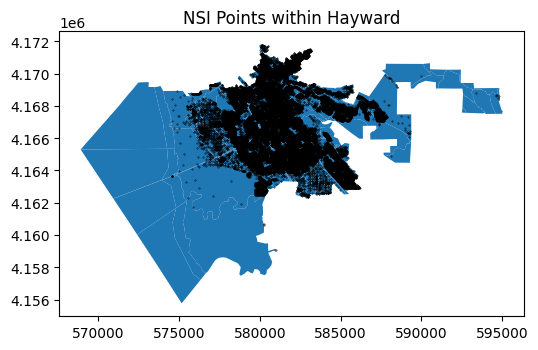

In [8]:
##### LOAD NSI DATA AND CONVERT TO APPROPRIATE CRS #####
nsi = gpd.read_file('./Input_Data/National/nsi_raw.geojson')
nsi = nsi.to_crs(epsg=crs_main)


##### RENAME AND DROP NSI COLUMNS AS APPROPRIATE #####
# Note - if different columns present in the dataframe other than NSI downloaded from 
# BRAILS++ and/or the NSI API, go to the rename_nsi_data function and comment out / add 
# appropriate column names as needed 
nsi = inv_natl.rename_nsi_data(nsi.copy())


# Merge NSI data with City-Specific Census Blocks and check for errors in NSI data
nsi = inv_natl.assign_point_block_and_track(nsi, hayward_blocks, hayward_tracts)

# Plot Results
fig, ax = plt.subplots(1,1, figsize = (6, 6))
hayward_blocks.plot(ax=ax)
nsi.plot(ax=ax, color ='black', markersize = 0.1)
ax.set_title('NSI Points within Hayward')


##### CREATE ADDITIONAL COLUMNS TO BE USED IN FOOTPRINT MERGE #####
nsi['NSI_DropFlag'] = 0 # This indicates whether a row should be dropped from the final inventory. 1 indicates yes, 0 indicates no 
nsi['NSI_DropNote'] = "" # Space for notes on the reason data points are dropped 
nsi['NSI_Source'] = 'NSI' # This tracks the original data source for each row 
nsi['NSI_OC_Update'] = None # This will contain updated Occupancy Class values throughout merge
nsi['NSI_DataUpdate'] = "" # Space for notes on steps throughout update 

# Save inventory
inv_natl.gdf_to_json(nsi, dir_intermediate + 'Hayward_NSI.json')

In [9]:
#  NOTE: Hazus 6.1 Inventory removes all AGR1 points with no square footage and/or footprint associated due to overesimation in some areas. 
# None of those points were found in Hayward, so this is not included here 

## **SECTION 3: Augment NSI Data using HIFLD Data**

Based on experimentation in Hayward, CA, the existing NSI data has some missing or incorrectly assigned information related to EDU and GOV occupancy types. This section uses imported HIFLD data to augment the existing NSI data

Data Downloaded Here: 
https://experience.arcgis.com/experience/2dedf7da18254d75b562cc51ba3a1653

### **SECTION 3.1: Update EDU1 Points**


 NSI Data in Hayward seemed to be missing a significant amount of school points (or they were labeled as GOV1 instead of EDU). This section aims to address that inconsistenty in the data. 
 


Public Schools: 38
Private Schools: 13


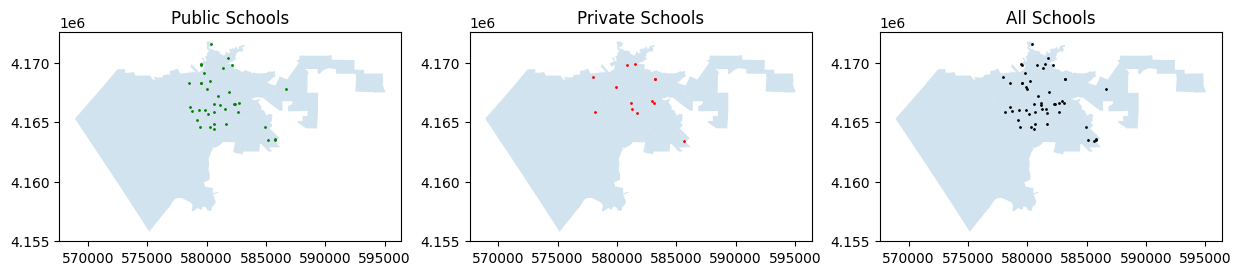

In [10]:
##### FIRST, ADDRESS EDU1 POINTS, WHICH CONSIST OF K-12 SCHOOLS #####

##### LOAD IMPORTED EDUCATIONAL HIFLD DATA AND CONVERT COORDINATES #####
public = gpd.read_file('./Input_Data/HIFLD/Public_Schools.geojson')
private = gpd.read_file('./Input_Data/HIFLD/Private_Schools.geojson')
public = public.to_crs(epsg=crs_main)
private = private.to_crs(epsg=crs_main)



##### MANUALLY REASSIGN SCHOOLS THAT WERE INCOREECTLY LOCATED - did this manually for one case in Hayward  #####
# NOTE: IF applying code in another area, comment this out 
# Ruus Elementary School 
transformer = Transformer.from_crs("EPSG:4326", f"EPSG:{crs_main}")
new_point = Point(transformer.transform(37.62699979615092,-122.07455518939621)) # Manually taken from Google Maps
row_index = public[public['NAME'].str.contains('RUUS')].index[0]
public.at[row_index, 'geometry'] = new_point




##### SORT FOR SCHOOLS WITHIN HAYWARD AND ASSIGN CENSUS TRACT AND BLOCK INFOMRATION #####

# Assign blocks and clean data
public_hayward, private_hayward, school_import = inv_natl.format_and_locate_edu1(public, private, hayward_tracts, hayward_blocks)

# Drop NAME (Used in future scripts to map to CA School Directory, but not used in National Synthesis Workflow)
school_import = school_import.drop(columns=['NAME'])

##### PLOT RESULTS #####
fig, ax = plt.subplots(1,3, figsize = (15, 12))
hayward_blocks.plot(ax=ax[0], alpha = 0.2)
public_hayward.plot(ax=ax[0], color ='green', markersize = 1)
ax[0].set_title('Public Schools')
hayward_blocks.plot(ax=ax[1], alpha = 0.2)
private_hayward.plot(ax=ax[1], color ='red', markersize = 1)
ax[1].set_title('Private Schools')
hayward_blocks.plot(ax=ax[2], alpha = 0.2)
school_import.plot(ax=ax[2], color ='black', markersize = 1)
ax[2].set_title('All Schools')
plt.show()

In [11]:
##### LOAD NSI DATA #####
nsi = inv_natl.json_to_gdf(dir_intermediate + 'Hayward_NSI.json', crs_main)

# Synthesize NSI EDU1 data that is within a 50m radius of a HIFLD EDU point, drop all other NSI EDU1 points 
# Set flag to true to display HIFLD and NSI EDU Points
plot_flag = False
drop_unpaired_nsi_edu1 = True # Flag to drop NSI EDU1 points that are more than 50m from HIFLD EDU1 
drop_gov1_near_edu1 = True  # Flag to drop GOV1 points that are within 50m of EDU1 points 

nsi, m = inv_natl.synthesize_edu1_and_HIFLD(nsi, school_import, crs_plot, plot_flag, drop_unpaired_nsi_edu1, drop_gov1_near_edu1)
if not isinstance(m, str):
    display(m)
    # Black = All NSI EDU1
    # Blue = HIFLD EDU1
    # Red = NSI EDU1 merged with HIFLD 

# Save updated NSI dataframe 
inv_natl.gdf_to_json(nsi, dir_intermediate + 'NSI_EDU1_Upgrade.json')

JSON File Saved


### **SECTION 3.2: Update EDU2 Points**


 NSI Data in Hayward seemed to be missing information related to colleges and universities (EDU2 points) including the location of campuses, points incorrectly designated as GOV1, and incorrect population information (i.e. Hayward had no GOV2 points available at all.) This section aims to address that inconsistenty in the data. 


Campus Polygons: 3
College/Univeristy Points: 4


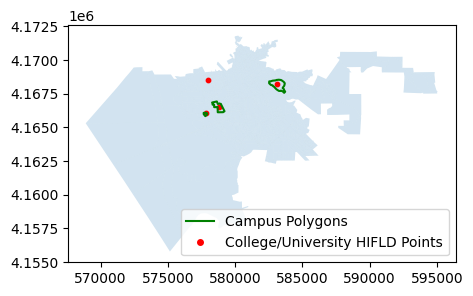

In [12]:
##### ADDRESS EDU2 POINTS, WHICH CONSIST OF COLLEGES/UNIVERSITIES #####

##### LOAD IMPORTED COLLEGE/UNIVERSITY HIFLD DATA AND CONVERT COORDINATES #####
univ = gpd.read_file('./Input_Data/HIFLD/Colleges_and_Universities_Campuses.geojson')
univ_pts = gpd.read_file('./Input_Data/HIFLD/Colleges_and_Universities.geojson')
univ = univ.to_crs(epsg=crs_main)
univ_pts = univ_pts.to_crs(epsg=crs_main)


##### SORT FOR SCHOOLS WITHIN HAYWARD AND ASSIGN CENSUS TRACT AND BLOCK INFOMRATION #####

# Assign blocks and clean data
univ_hayward, univ_pts_hayward = inv_natl.locate_edu2(univ, univ_pts, hayward_tracts, hayward_blocks)


##### PLOT HIFLD DATA #####
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
hayward_blocks.plot(ax=ax, alpha=0.2)
univ_hayward.boundary.plot(ax=ax, color='green') 
univ_pts_hayward.plot(ax=ax, color='red', markersize=10)
univ_hayward_line = mlines.Line2D([], [], color='green', label='Campus Polygons')
univ_pts_hayward_point = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=4, label='College/University HIFLD Points')
ax.legend(handles=[univ_hayward_line, univ_pts_hayward_point], loc='lower right')
plt.show()


No EDU2 points in NSI data


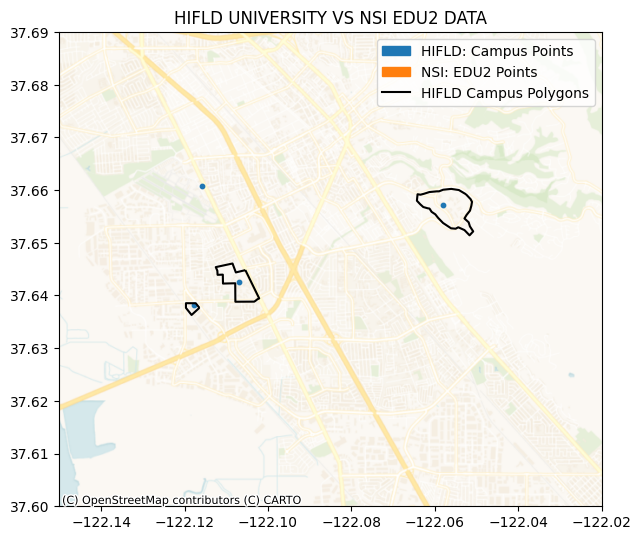

In [13]:
##### PLOT HIFLD EDU2 VS NSI EDU2 -- THIS CELL ONLY PLOTS DATA #####

nsi = inv_natl.json_to_gdf(dir_intermediate + 'Hayward_NSI.json', crs_main)
edu2 = nsi[nsi['NSI_OccupancyClass'] == 'EDU2']

##### DISPLAY SCHOOL POINTS #####
fig, ax = plt.subplots(figsize = (7,7))

if len(edu2) > 0: 
    univ_pts_hayward.copy().to_crs(crs_plot).plot(ax=ax, color = 'tab:orange', markersize=10)
else: 
    print('No EDU2 points in NSI data')

univ_pts_hayward.copy().to_crs(crs_plot).plot(ax=ax, color = 'tab:blue',  markersize=10)
univ_hayward.copy().to_crs(crs_plot).boundary.plot(ax=ax, color='black') 

# Bounds
plt.xlim(xbounds)
plt.ylim(ybounds)

# Add the OpenStreetMap basemap
ctx.add_basemap(ax, crs='EPSG:4269', source=ctx.providers.CartoDB.VoyagerNoLabels)

handles = [
    mpatches.Patch(color='tab:blue', label='HIFLD: Campus Points'),
    mpatches.Patch(color='tab:orange', label='NSI: EDU2 Points'),
    mlines.Line2D([], [], color='black', label='HIFLD Campus Polygons')
]
ax.legend(handles=handles)

# Show the plot
plt.title('HIFLD UNIVERSITY VS NSI EDU2 DATA')
plt.show()

In [14]:
##### MERGE CAMPUS HIFLD DATA INTO NSI DATAFRAME 
# Load NSI Data 
nsi = inv_natl.json_to_gdf(dir_intermediate + 'NSI_EDU1_Upgrade.json', crs_main)

##### POINTS WITHOUT CAMPUS POLYGONS #####
# Find points without associated campus polygons and append them in NSI data
edu2_no_campus = inv_natl.prepare_pts_without_campuses(univ_pts_hayward, univ_hayward, nsi.copy())
nsi = pd.concat([nsi,edu2_no_campus])

# ##### POINTS WITH CAMPUS POLYGONS, BUT WITHOUT GOV1 POINTS INSIDE #####
# # Find points and append them in NSI data
edu2_no_gov1 = inv_natl.prepare_pts_without_gov1(univ_pts_hayward, univ_hayward, nsi.copy())
nsi = pd.concat([nsi,edu2_no_gov1])

##### POINTS WITH CAMPUS POLYGONS, WITH GOV1 POINTS INSIDE #####
# Find GOV1 points within campus polygons and reassign them as EDU2

# Set flag to determine if NSI population should be scaled within campus polygons to match HIFLD campus enrollment 
scale_edu2_pop = True
nsi = inv_natl.merge_pts_with_campuses(univ_hayward, nsi.copy(), scale_edu2_pop)

##### SAVE NSI #####
inv_natl.gdf_to_json(nsi, dir_intermediate + 'NSI_EDU1_EDU2_Upgrade.json')

JSON File Saved


In [15]:
##### RUN CHECK: FOLLOWING NUMBERS SHOULD MATCH (WITHIN SCALING/ROUNDING ERROR) #####
school_num = 0 # Can change number here to look at different universities 
one_univ = univ_hayward.iloc[[school_num]]
one_univ_convert = nsi.sjoin(one_univ[['UNIQUEID','POPULATION','TOT_ENROLL','TOT_EMP','geometry']], how='inner')
print('NSI Day',sum(one_univ_convert['NSI_Population_Day']))
print('Imported School Population',one_univ['POPULATION'].values)

NSI Day 18004.0
Imported School Population [18010]


### **SECTION 3.3: Update GOV2 Points**


 NSI Data in Hayward seemed to be missing information related to emergency response including the location of fire stations, police stations, and emergency options centers. These points may be present in NSI and mislabeled as GOV1. This section aims to address that inconsistently in the data. 

In [ ]:
##### ADDRESS GOV2 POINTS, WHICH CONSIST OF EMERGENCY RESPONSE BUILDINGS #####

##### LOAD IMPORTED HIFLD DATA, CONVERT COORDINATES, AND ASSIGN CENSUS #####
fire = gpd.read_file('./Input_Data/HIFLD/Fire_and_Emergency_Medical_Service_(EMS)_Stations.geojson')
police = gpd.read_file('./Input_Data/HIFLD/Local_Law_Enforcement_Locations.geojson')
local_eoc = gpd.read_file('./Input_Data/HIFLD/Local_Emergency_Operations_Centers_EOC.geojson')
state_eoc = gpd.read_file('./Input_Data/HIFLD/State_Emergency_Operations_Centers_EOC.geojson')

# Convert Coordinates
fire = fire.to_crs(epsg=crs_main)
police = police.to_crs(epsg=crs_main)
local_eoc = local_eoc.to_crs(epsg=crs_main)
state_eoc = state_eoc.to_crs(epsg=crs_main)

# Assign Census Block and Tract to HIFLD Data
fire = inv_natl.assign_census_hifld(fire, hayward_blocks, hayward_tracts)
police = inv_natl.assign_census_hifld(police, hayward_blocks, hayward_tracts)
local_eoc = inv_natl.assign_census_hifld(local_eoc, hayward_blocks, hayward_tracts)
state_eoc = inv_natl.assign_census_hifld(state_eoc, hayward_blocks, hayward_tracts)


##### MERGE DATA FOR FUTURE USE #####

# Reduce columns and set class
fire = fire[['geometry', 'CensusBlock', 'CensusTract']]
fire['NSI_OccupancyClass'] = "GOV2-FIRE"
police = police[['geometry', 'CensusBlock', 'CensusTract']]
police['NSI_OccupancyClass'] = "GOV2-POLICE"
local_eoc = local_eoc[['geometry', 'CensusBlock', 'CensusTract']]
local_eoc['NSI_OccupancyClass'] = "GOV2-OPERATIONS"
state_eoc = state_eoc[['geometry', 'CensusBlock', 'CensusTract']]
state_eoc['NSI_OccupancyClass'] = "GOV2-OPERATIONS"

# Concatinate and prepare for merge
gov2_import = pd.concat([fire, police, local_eoc, state_eoc], ignore_index=True, sort=False)


##### SYNTHESIZE NSI GOV2 AND HIFLD POINTS #####
nsi = inv_natl.json_to_gdf(dir_intermediate + 'NSI_EDU1_EDU2_Upgrade.json', crs_main)

# Set flag to true to display HIFLD and NSI GOV2 Points
plot_flag = False
drop_unpaired_nsi_gov2 = True # Flag to drop NSI GOV2 points that are more than 50m from HIFLD EDU1 
drop_gov1_near_gov2 = True  # Flag to drop GOV1 points that are within 10m of GOV2 points 


nsi, m = inv_natl.synthesize_gov2_and_HIFLD(nsi, gov2_import, crs_plot, plot_flag, drop_unpaired_nsi_gov2, drop_gov1_near_gov2)
if not isinstance(m, str):
    display(m)
    # Black = All NSI GOV2
    # Blue = HIFLD Police Stations
    # Red = HIFLD Fire Stations
    # Green = HIFLD Emergency Operations

##### SAVE NSI #####
inv_natl.gdf_to_json(nsi, dir_intermediate + 'NSI_EDU1_EDU2_GOV2_Upgrade.json')

: 

## **SECTION 4: Establish Variables and Merge Duplicate BIDs**

In [ ]:
#### LOAD IN UPDATED NSI DATA #####
nsi = inv_natl.json_to_gdf(dir_intermediate + 'NSI_EDU1_EDU2_GOV2_Upgrade.json', crs_main)

#### CREATE ID AND SET COLUMNS #####
filter_under_450 = False # Filter out NSI points under than 450 square feet 
nsi = inv_natl.add_nsi_tracking_columns(nsi, filter_under_450)

### COMPUTE MIN AND MAX OF RANGE OF RES UNITS BASED ON OCCUPANCY CLASS ### 
nsi = inv_natl.compute_min_mix_units(nsi)


In [ ]:
### DEFINE COLUMNS TO BE SUMMED OR COVERTED TO LISTS WHEN COMBINED ### 
# sum_columns get summed when points are merged (i.e. replacement cost)
# list_columns get put into lists (if information differs) when points are merged (i.e. foundation type)

# Set category of certain column names
excluded = ['geometry', 'CensusBlock', 'CensusTract', 'NSI_ID', 'NSI_OccupancyClass', 'NSI_DropFlag', 'NSI_DropNote', 'NSI_OC_Update',
            'NSI_FootprintID', 'DistanceToFtpt', 'ClosestFtpt_ID', 'NSI_MergeFlag','NSI_DataUpdate']
sum_columns = ['NSI_PopOver65_Day', 'NSI_PopUnder65_Day', 'NSI_Population_Day',
                    'NSI_PopOver65_Night', 'NSI_PopUnder65_Night', 'NSI_Population_Night','NSI_ContentValue','NSI_ReplacementCost',
                    'NSI_StructureValue','NSI_MinResUnits', 'NSI_MaxResUnits','NSI_NumPoints']
list_columns = ['NSI_FoundationType','NSI_FoundationHeight','NSI_BuildingType','NSI_MedYearBuilt',
                'NSI_NumberOfStories', 'NSI_Source', 'NSI_OrigSource', 'NSI_OrigFtptSource','NSI_BID','NSI_ID_List','NSI_TotalAreaSqFt']

# Print unassigned columns 
counter = 0
for col in nsi.columns: 
    if (col not in sum_columns) and (col not in list_columns) and (col not in excluded): 
        print(col, 'is unassigned')
        counter += 1
if counter == 0: 
    print('No Unassigned Columns')

No Unassigned Columns


In [ ]:
##### Group NSI rows with same BID ####

##### SPLIT DATA BASED ON DROP_FLAG #####
nsi_length = len(nsi) # Used for tracking purposes 
nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 

# Assuming values with same BID are all intended to be in the same footprint moving forward 
nsi0 = inv_natl.merge_duplicate_bid(nsi0, list_columns, sum_columns)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### SAVE NSI #####
inv_natl.gdf_to_json(nsi, dir_intermediate + 'NSI_for_Merge.json')

JSON File Saved


In [ ]:
# # ## UNCOMMENT TO CHECK EXAMPLE 
# # bid = '849VMX88+3WM-5-5-6-5'
# # bid = '849VMW64+585-0-0-0-0'
# # bid = '849VJWRC+365-1-8-1-8'
# bid = '849VMX4P+7JC-3-4-4-4'
# # bid = '849VJWWH+H4R-4-3-3-3'
# nsi[nsi['NSI_BID']==bid][['NSI_OccupancyClass','NSI_OC_Update','NSI_BID','NSI_NumPoints','NSI_ReplacementCost',"NSI_DropFlag",'NSI_DropNote','NSI_DataUpdate',
#                           'NSI_MinResUnits','NSI_MaxResUnits']]


## **SECTION 5: Associate NSI Points with Footprint Information**

In [ ]:
##### LOAD PREPROCESSED DATA FOR MERGE #####
nsi = inv_natl.json_to_gdf(dir_intermediate + 'NSI_for_Merge.json', crs_main)

##### DISPLAY NUMBER OF POINTS #####
nsi_length = len(nsi) # Used for tracking purposes 
print('NSI:', len(nsi))
print('Footprints:', len(footprints))

NSI: 41217
Footprints: 38355


In [ ]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in nsi.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **SECTION 5.1: MergeFlag1 - Address Cases with 1 Footprint and 1 Point**

In [ ]:
##### SPLIT DATA BASED ON DROP_FLAG #####
nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 

##### RUN FUNCTION TO MERGE CASES WITH ONE POINT WITHIN ONE FOOTPRINT #####
nsi0, map = inv_natl.merge_intersecting(nsi0, footprints, crs_plot)

# Plot overlapping footprints if found 
if isinstance(map, str):
    print(map)
else: 
    display(map)

# Update MergeFlag99 for footprints that are larger than their designated occupancy type 
nsi0 = inv_natl.update_mergeflag99(nsi0, footprints, mergeflag = 1)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
inv_natl.check_post_merge_duplicates(nsi.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(nsi.copy(), dir_intermediate + 'MergeFlag1.json')


Points within Footprints: 35975
Unique points within Footprints (one point per footprint): 33024
Data with Associated Footprints (should match row above): 33024
Passed Check: No overlapping footprints found
Passed Check: No duplicates found
JSON File Saved


### **SECTION 5.2: MergeFlag2 - Address Cases with 1 Footprint and Multiple Points**

In [ ]:
##### LOAD DATA #####
nsi = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag1.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "NSI_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
nsi = inv_natl.drop_ids(nsi, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 

#### RUN FUNCTION TO MERGE CASES WITH MULTIPLE POINTS WITHIN ONE FOOTPRINT #####
# Set flag to print odd occupancy pairings, including (RES + IND), (RES + GOV), and (EDU + IND) - does not change function outputs, only displays 
print_odd_occupancy_pairings = False
nsi0 = inv_natl.address_overlapping_points(nsi0.copy(), footprints.copy(), list_columns, sum_columns, manually_assigned_occupancy, print_odd_occupancy_pairings, crs_plot)

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
nsi['NSI_FootprintID'] = nsi['NSI_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(nsi.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(nsi.copy(), dir_intermediate + 'MergeFlag2.json')

Number of Points Remaining: 4775
Number of Footprints Remaining: 5331
Number of Points within Footprint Polygons: 3006
Number of Footprints with Multiple Points (Looping Through These Now): 1017
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


### **SECTION 5.3: Drop Selected Data**

In this section, remaining GOV1, IND4, and IND5 points that are not paired with a footprint are dropped. By observation in Hayward, it seems like these points are either centered within a building, or do not seem to represent a structure (located in marshlands, along transit lines, etc.)

In [ ]:
##### LOAD DATA #####
nsi = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag2.json', crs_main)

##### SPLIT DATA BASED ON DROP_FLAG #####
nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 

##### COLLECT REMAINING GOV1, IND4, and IND5 POINTS #####
remaining_points, remaining_ftpt = inv_natl.find_remaining(nsi0, footprints, 'NSI_FootprintID','NSI_MergeFlag')
points_to_drop = remaining_points[((remaining_points['NSI_OccupancyClass']=='IND4') | (remaining_points['NSI_OccupancyClass']=='IND5') | (remaining_points['NSI_OccupancyClass']=='GOV1'))]
ids_to_drop = [item for sublist in points_to_drop['NSI_ID'] for item in (sublist if isinstance(sublist, list) else [sublist])]
print(len(ids_to_drop), 'points to drop')


### DROP POINTS ###
nsi0 = inv_natl.drop_ids(nsi0, ids_to_drop, 'IND4, IND5, or GOV1 point outside of footprint')

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
nsi['NSI_FootprintID'] = nsi['NSI_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(nsi.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(nsi.copy(), dir_intermediate + 'MergeFlag2_dropped.json')

Number of Points Remaining: 1769
Number of Footprints Remaining: 4314
707 points to drop
Passed Check: No duplicates found
JSON File Saved


In [ ]:
# # ### UNCOMMENT CODE TO PLOT POINTS BEING DROPPED AND REMAINING FOOTPRINTS #####

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in points_to_drop.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red',
#                         popup=row[['NSI_OccupancyClass', 'NSI_ID','NSI_FootprintID']]).add_to(m)
    
# display(m)

### **SECTION 5.4: MergeFlag310 - Merge Points within 10m of a Footprint**

In [ ]:
# Load data 
nsi = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag2_dropped.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "NSI_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
nsi = inv_natl.drop_ids(nsi, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
nsi0 = nsi[nsi['NSI_DropFlag']!=1].copy() # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1].copy() # Dropped - these should not be used in merge 


##### CONDUCT MERGE #####

# Get list of census blocks
CB_list = hayward_blocks['GEOID10'].unique()

# Merge data using function 
nsi0 = inv_natl.distance_limit_merge(CB_list, nsi0.copy(), footprints, manually_assigned_occupancy, list_columns, sum_columns, hayward_blocks, crs_plot,
                            distance_limit = 10, 
                            use_surrounding_blocks = True, # Footprints in surrounding census blocks will be considered for each NSI point
                            use_partial_footprints = True, # Footprints with MergeFlag = 99 will be considered for each NSI point (once empty footprints in distance limit have been exhausted)
                            use_full_footprints = True, # Full footprints will be considered for each NSI point (once empty and partial footprints in distance limit have been exhausted)
                            merge_flag = 310, 
                            print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 


##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
nsi['NSI_FootprintID'] = nsi['NSI_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(nsi.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(nsi.copy(), dir_intermediate + 'MergeFlag310.json')


Number of Points Remaining: 1062
Number of Footprints Remaining: 4314
Processing 1894 Census Blocks
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [ ]:
# ## UNCOMMENT TO VIEW PREVIOUS MERGE IN DETAIL 

# # Get footprints remaining prior to recent merge to view 
# nsi = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag2_dropped.json', crs_main)
# nsi = nsi[nsi['NSI_DropFlag']==0]
# remaining_points, remaining_ftpt = inv_natl.find_remaining(nsi, footprints,'NSI_FootprintID','NSI_MergeFlag')

# # Get newly merged points 
# mf3 = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# mf3 = mf3[mf3['NSI_MergeFlag']==310]

# # Plot
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)

# # Add remaining points     
# for idx, row in mf3.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red').add_to(m)
# display(m)

### **SECTION 5.5: MergeFlag3100 - Merge Points within 100m of a Footprint**

In [ ]:
# Load data 
nsi = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag310.json', crs_main)


##################################################################################################################################

############# THE FOLLOWING CAN BE FILLED OUT TO MAKE MODIFICATIONS BASED ON THE PRINTED OUT "ODD OCCUPANCY PAIRINGS" #################

##### MANUALLY ASSIGN OCCUPANCY CLASS FOR FOOTPRINTS HERE #####
manually_assigned_occupancy_data = {
    "FootprintID":[], # Put FootprintID values in this list
    "NSI_OccupancyClass":[]} # Put corresponding occupancy class values in this list. Can enter string or list, 
                             # i.e. "NSI_OccupancyClass":['RES1',['IND3','RES3C]] would correspond to first and second FootprintID entered in list above
manually_assigned_occupancy = pd.DataFrame(manually_assigned_occupancy_data)

##### MANUALLY DROP NSI POINTS HERE #####
ids_to_drop = [] # Place NSI_ID values here that should be dropped from the merge 
nsi = inv_natl.drop_ids(nsi, ids_to_drop, 'Manually dropped due to occupancy class incompatibility')

##################################################################################################################################


##### SPLIT DATA BASED ON DROP_FLAG #####
nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 


##### CONDUCT MERGE #####

# Get list of census blocks
CB_list = hayward_blocks['GEOID10'].unique()

# Merge data using function 
nsi0 = inv_natl.distance_limit_merge(CB_list, nsi0.copy(), footprints, manually_assigned_occupancy, list_columns, sum_columns, hayward_blocks, crs_plot,
                            distance_limit = 100, 
                            use_surrounding_blocks = False, # Footprints in surrounding census blocks will be considered for each NSI point
                            use_partial_footprints = True, # Footprints with MergeFlag = 99 will be considered for each NSI point (once empty footprints in distance limit have been exhausted)
                            use_full_footprints = True, # Full footprints will be considered for each NSI point (once empty and partial footprints in distance limit have been exhausted)
                            merge_flag = 3100,
                            print_odd_occupancy_pairings = False) # If True, some occupancy class pairs will be printed out if they are merged into same footprint to manually check 



##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
nsi['NSI_FootprintID'] = nsi['NSI_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(nsi.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(nsi.copy(), dir_intermediate + 'MergeFlag3100.json')

Number of Points Remaining: 489
Number of Footprints Remaining: 4035
Processing 1894 Census Blocks
10% complete
20% complete
30% complete
40% complete
50% complete
60% complete
70% complete
80% complete
90% complete
100% complete
Passed Check: No duplicates found
JSON File Saved


In [ ]:
# ## VIEW PREVIOUS MERGE IN DETAIL 

# # Get footprints remaining prior to recent merge to view 
# nsi = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag310.json', crs_main)
# nsi = nsi[nsi['NSI_DropFlag']==0]
# remaining_points, remaining_ftpt = inv_natl.find_remaining(nsi, footprints,'NSI_FootprintID','NSI_MergeFlag')

# # Get newly merged points 
# mf3 = inv_natl.json_to_gdf(dir_intermediate + '/MergeFlag3100.json', crs_main)
# mf3 = mf3[mf3['NSI_MergeFlag']==3100]

# # Plot
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)

# # Add remaining points     
# for idx, row in mf3.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red').add_to(m)
# display(m)

### **SECTION 5.6: Review Data, Address Remaining Points**

In [ ]:
# ##### UNCOMMENT CODE TO PLOT REMAINING DATA #####
# # Gray points represent paired NSI data 
# # Dropped NSI points are not displayed 
# # Red points are unpaired NSI data 
# # Census blocks are shown in gray 
# # Reamining footprints are shown in blue 
# # "Not full" footprints are shown in green

# #  Load data
# nsi = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag3100.json', crs_main)

# ##### SPLIT DATA BASED ON DROP_FLAG #####
# nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
# nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 


# # Find footprints associated with parially full points 
# not_full_nsi = nsi0[nsi0['NSI_MergeFlag']==99]
# not_full_ftpt = footprints[footprints['FootprintID'].isin(not_full_nsi['NSI_FootprintID'])]


# ##### CREATE MAP #####
# nsi['NSI_FootprintID'] = nsi0['NSI_FootprintID'].apply(lambda x: int(x) if pd.notna(x) else x)
# remaining_points, remaining_ftpt = inv_natl.find_remaining(nsi0, footprints,'NSI_FootprintID','NSI_MergeFlag')

# # Display remaining population
# total_pop_night = remaining_points['NSI_Population_Night'].dropna().sum()
# print('Night Population in Remaining Points:',total_pop_night)
# total_pop_day = remaining_points['NSI_Population_Day'].dropna().sum()
# print('Day Population in Remaining Points:',total_pop_day)
# print('Replacement Cost in Remaining Points:',sum(remaining_points['NSI_ReplacementCost']))

# # Create a base map
# m = folium.Map(location=[footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, footprints.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(hayward_blocks.copy().to_crs(crs_plot), color = 'gray').add_to(m)
# # folium.GeoJson(footprints.copy().to_crs(crs_plot), color = 'blue').add_to(m)
# folium.GeoJson(remaining_ftpt.copy().to_crs(crs_plot), color = 'blue').add_to(m)
# folium.GeoJson(not_full_ftpt.copy().to_crs(crs_plot), color = 'green').add_to(m)

# # Add paired points   
# # for idx, row in nsi0[nsi0['NSI_MergeFlag']!=0].copy().to_crs(crs_plot).iterrows():
# #     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
# #                         radius=1, 
# #                         color='gray', 
# #                         fill=True, 
# #                         fill_color='gray',
# #                         popup=row[['NSI_OccupancyClass', 'NSI_ID','NSI_FootprintID']]).add_to(m)

# # Add remaining points  
# for idx, row in remaining_points.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='red', 
#                         fill=True, 
#                         fill_color='red',
#                         popup=row[['NSI_OccupancyClass', 'NSI_ID','NSI_FootprintID','CensusBlock']]).add_to(m)

# display(m)

In [8]:
##### BASED ON ABOVE PLOT, WE DETERMINED THAT THE REMAINING NSI POINTS WILL BE DROPPED #####

# Load Dataset
nsi = inv_natl.json_to_gdf(dir_intermediate + 'MergeFlag3100.json', crs_main)
nsi_length = len(nsi)

##### SPLIT DATA BASED ON DROP_FLAG #####
nsi0 = nsi[nsi['NSI_DropFlag']!=1].copy() # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1].copy() # Dropped - these should not be used in merge 

# Find remaining points without footprints and flag them as dropped
nsi0['NSI_FootprintID'] = nsi0['NSI_FootprintID'].apply(lambda x: int(x) if pd.notna(x) else x)
remaining_points, remaining_ftpt = inv_natl.find_remaining(nsi0, footprints,'NSI_FootprintID','NSI_MergeFlag')
nsi0 = inv_natl.drop_ids(nsi0, remaining_points['NSI_ID'].values, 'Points remaining after MergeFlag 3100')

##### REUNITE DATA BASED ON DROP_FLAG AND CHECK THAT ALL POINTS WERE RETAINED #####
nsi = inv_natl.recombine_dropped_data(nsi0, nsi1, nsi_length)

##### CHECK FOR DUPLICATED FOOTPRINTS IN MERGED DATA #####
nsi['NSI_FootprintID'] = nsi['NSI_FootprintID'].astype('Int64')
inv_natl.check_post_merge_duplicates(nsi.copy())

##### SAVE JSON FILE #####
inv_natl.gdf_to_json(nsi.copy(), dir_intermediate + 'National_MergedPoints.json')


Number of Points Remaining: 247
Number of Footprints Remaining: 3914
Passed Check: No duplicates found
JSON File Saved


## **SECTION 6: Convert Merged NSI Points into Footprint-Level Inventory**

STEPS:
-  Relocate data based on footprint centroid
-  Drop points that are marked with NSI_DropFlag
-  Drop columns that were used for intermediate tracking purposes 
-  Rename columns appropriately 
-  Convert data types of given columns 


RESULT:
-  Export inventory with footprint geometry 
-  Export inventory with point geometry (at centroid of footprints)

In [ ]:
# Load point data 
nsi = inv_natl.json_to_gdf(dir_intermediate + 'National_MergedPoints.json', crs_main)
nsi0 = nsi[nsi['NSI_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['NSI_DropFlag']==1] # Dropped - these should not be used in merge 

# Drop geometry information in preparation for merge 
nsi0 = nsi0.drop(columns = ['geometry'])

# Drop additional columns used for tracking purposes 
nsi0 = nsi0.drop(columns = ['CensusTract','CensusBlock','NSI_DropFlag','NSI_DropNote','DistanceToFtpt', 'ClosestFtpt_ID','NSI_ID', 'NSI_OccupancyClass', 'NSI_DataUpdate'])
nsi0 = nsi0.rename(columns={'NSI_OC_Update': 'NSI_OccupancyClass'})
nsi0 = nsi0.rename(columns={'NSI_ID_List': 'NSI_ID'})

# Convert numeric, single-entry columns to appropriate type 
float_columns = ['NSI_ContentValue', 'NSI_StructureValue', 'NSI_ReplacementCost','NSI_PopOver65_Night',
                 'NSI_PopUnder65_Night', 'NSI_Population_Night', 'NSI_PopOver65_Day', 'NSI_PopUnder65_Day', 'NSI_Population_Day']
int_columns = ['NSI_NumPoints', 'NSI_FootprintID', 'NSI_MergeFlag', 'NSI_MinResUnits', 'NSI_MaxResUnits']   

# Convert columns to appropriate type 
for col in float_columns:
    nsi0[col] = nsi0[col].astype(float)
for col in int_columns:
    nsi0[col] = nsi0[col].astype(int)
nsi0['NSI_OccupancyClass'] = nsi0['NSI_OccupancyClass'].apply(inv_natl.convert_to_list)
nsi0['NSI_ID'] = nsi0['NSI_ID'].apply(inv_natl.convert_to_list)

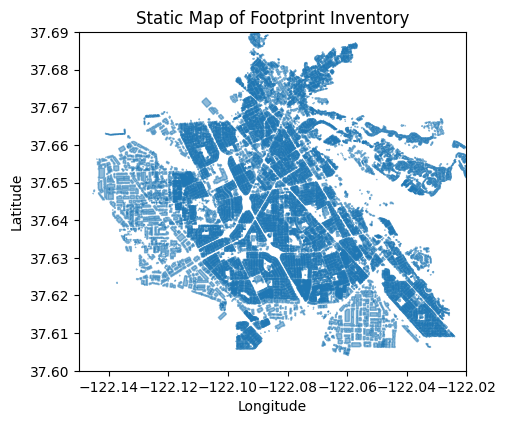

JSON File Saved


In [ ]:
# Create baseline inventory 
ftpt_inv = footprints.copy()
orig_inv_length = len(ftpt_inv)
nsi0['National_Flag'] = 1

# Merge unique footprint information in with baseline footprint inventory and perform checks for dropped points
ftpt_inv = ftpt_inv.merge(nsi0, left_on='FootprintID', right_on='NSI_FootprintID', how='left')
if len(ftpt_inv) != orig_inv_length: 
    raise ValueError('Footprints Dropped - Step 1')

if len(ftpt_inv[ftpt_inv['National_Flag']==1]) != len(nsi0): 
    raise ValueError('Footprints Dropped - Step 2')

# Drop redundant footprint column
ftpt_inv = ftpt_inv.drop(columns = ['NSI_FootprintID'])
ftpt_inv['National_Flag'] = ftpt_inv['National_Flag'].fillna(0)

# Plot inventory
fig, ax = plt.subplots(figsize=(5,5))
ftpt_inv.to_crs(crs_plot).plot(ax=ax, color='tab:blue', edgecolor='tab:blue', alpha=0.5, label = 'All Footprints')
plt.title('Static Map of Footprint Inventory')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()

# Export footprint inventory 
inv_natl.gdf_to_json(ftpt_inv, dir_attribution + 'National_Inventory_Polygon.json')

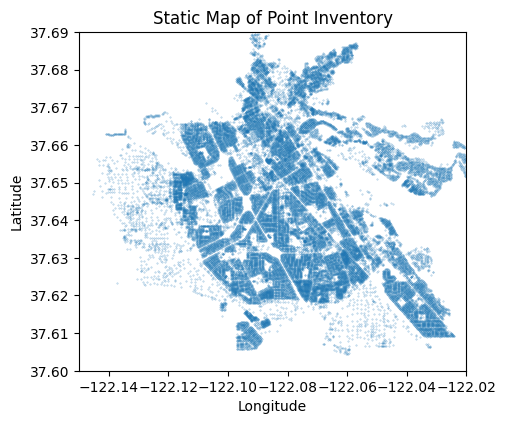

JSON File Saved


In [ ]:
# Modify footprint inventory geometry to be the centroid of each footprint 
ftpt_inv = ftpt_inv.rename(columns={'geometry': 'ftpt_geometry'})
ftpt_inv['geometry'] = ftpt_inv['ftpt_geometry'].centroid
ftpt_inv.set_geometry('geometry')
ftpt_inv['Footprint_Flag'] = 1

# Plot inventory
fig, ax = plt.subplots(figsize=(5,5))
ftpt_inv.to_crs(crs_plot).plot(ax=ax, color='tab:blue', edgecolor='tab:blue', markersize = 0.1, alpha=0.5, label = 'All Footprints')
plt.title('Static Map of Point Inventory')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()

# Save inventory 
inv_natl.gdf_to_json(ftpt_inv, dir_attribution + 'National_Inventory_Point.json')

## **RESOLVE DISAGREEMENT**

In [ ]:
# Load Inventory
inv_raw = inv_natl.json_to_gdf(dir_attribution + 'National_Inventory_Point.json', crs_main)

# Create modifiable instance of raw inventory 
inv_mod = inv_raw.copy()

In [ ]:
## RESOLVE WITHIN-SOURCE DISAGREEMENT (MINIMAL BETWEEN SOURCE DISAGREEMENT DUE TO USE OF ONlY NATIONAL DATASETS)

# Columns that are modified to a single value (down from a list) by selecting mode 
modified_to_single_solo = ['NSI_BuildingType', 'NSI_MedYearBuilt', 'NSI_NumberOfStories', 'NSI_TotalAreaSqFt']
for col in modified_to_single_solo:
    inv_mod[col + '_Single'] = inv_mod[col].apply(inv_natl.modify_to_single_val)

# Assign paired selections for foundation type and height 
# These variables, since they are directly related, will always be taken from the same original data point
inv_mod[['NSI_FoundationType_Single', 'NSI_FoundationHeight_Single']] = inv_mod[['NSI_FoundationType', 'NSI_FoundationHeight']].apply(inv_natl.modify_to_single_val_paired, axis=1).apply(pd.Series)

# Update occupancy class based on rulesets specific for NSI/HIFLD Occupancy Class 
inv_mod[['NSI_OccupancyClass_Single','NSI_OccupancyClass_MixedUse']] = inv_mod['NSI_OccupancyClass'].apply(inv_natl.modify_to_single_nsi_occupancy).apply(pd.Series)
inv_mod['NSI_OccupancyClass_Single'] = inv_mod['NSI_OccupancyClass_Single'].fillna('')

# Simplify NSI Occupancies Containing RES1 to RES1 
inv_mod.loc[inv_mod['NSI_OccupancyClass_Single'].str.contains('RES1', na=False), 'NSI_OccupancyClass_Single'] = 'RES1'

In [ ]:
## CHRISTAINOS: IF YOU NEED CODE TO IMPUTE GAPS IN THE DATA OR INFER STRUCTURE TYPE OR SOMETHING, LET ME KNOW 

inv_mod.columns

## EXPORT TO R2D -- (THIS WON'T RUN, NEED YOUR OWN COLUMNS)

In [ ]:
r2d['Longitude'] = r2d['geometry'].x
r2d['Latitude'] = r2d['geometry'].y
r2d = r2d[['Latitude','Longitude','PlanArea','NumberOfStories','YearBuilt','ReplacementCost','ReplacementCost_Hazus','StructureType','BuildingType','OccupancyClass_clean','OccupancyClass', 'NumberOfUnits','NightPopulation','CensusBlock','CensusTract','FootprintID','geometry']]

# Assign design level and height class (used in regional analysis)
r2d = infr.find_design_level(r2d, 'StructureType', 'YearBuilt', 'DesignLevel')
r2d = infr.find_height_class(r2d, 'StructureType', 'NumberOfStories', 'HeightClass')

# Add id
r2d.insert(0, 'id', range(len(r2d)))

# Rename occupancy class columns for R2D use
r2d = r2d.rename(columns={'OccupancyClass': 'OccupancyClass_Actual',
                          'OccupancyClass_clean': 'OccupancyClass'})

# Save inventory
r2d.to_csv(dir_r2d + 'R2D_Inventory.csv', index = False)
inv_natl.gdf_to_json(r2d, dir_r2d + 'R2D_Inventory.json')